do I need log the results of each k, what results?
- quantile estimate
- loglik
- aic
- bic

In [64]:
from src.gmm import GMM
from src.dg import DataGenerator

import torch
import numpy as np

import matplotlib.pyplot as plt
from scipy.stats import norm, logistic


In [65]:
dist = 'Logistic' # Logistic, Normal, Student t
alpha = 0.7
d = 3
N = 2000

dg = DataGenerator(dist, alpha)
X, M = dg.generate(N, d)

In [66]:
def true_quantile(dist, q=0.1):
    if dist == 'Normal':
        return norm.ppf(q)
    elif dist == 'Logistic':
        return logistic.ppf(q)

# PART I: Iterative EM -- Comparing AIC, BIC, and loglik over $k$

In [67]:
cov_type = 'uni_id' # diag, id, uni_diag, uni_id
gmm = GMM(X, M, cov_type)

In [68]:
n_k = 10
start = 0
step = 1
n_mc = 500

kk, q, loglik, aic, bic = gmm.iterEM(n_k, start, step, n_mc)

0 1.00 -9472.16 18952.32 18974.72
Converged at iteration 1, rel_change=0.00e+00
1 2.00 -9472.16 18960.32 19005.13
Converged at iteration 1, rel_change=0.00e+00
2 3.00 -9472.16 18968.32 19035.53
Converged at iteration 1, rel_change=0.00e+00
3 4.00 -9472.16 18976.32 19065.93
Converged at iteration 1, rel_change=0.00e+00
4 5.00 -9472.16 18984.32 19096.34
Converged at iteration 1, rel_change=0.00e+00
5 6.00 -9472.16 18992.32 19126.74
Converged at iteration 1, rel_change=0.00e+00
6 7.00 -9472.16 19000.32 19157.14
Converged at iteration 1, rel_change=0.00e+00
7 8.00 -9472.16 19008.32 19187.55
Converged at iteration 1, rel_change=0.00e+00
8 9.00 -9472.16 19016.32 19217.95
Converged at iteration 1, rel_change=0.00e+00
9 10.00 -9472.16 19024.32 19248.35


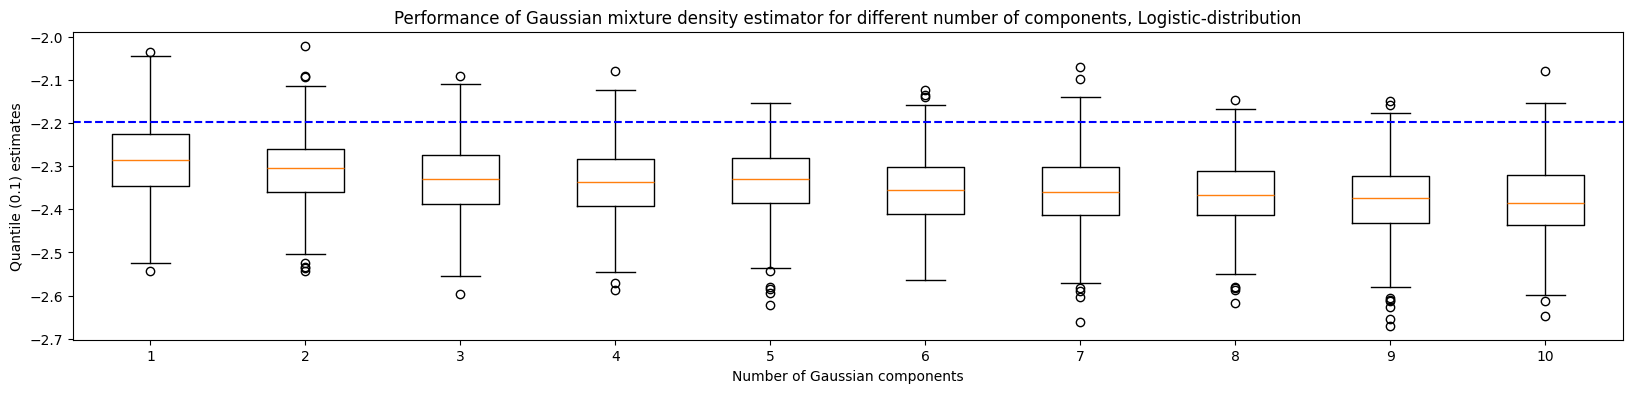

In [69]:
positions = np.array(kk)

plt.figure(figsize=(20, 4))
plt.boxplot(q, positions=positions)

plt.axhline(y=true_quantile(dist), color='blue', linestyle='--')
plt.xlabel("Number of Gaussian components")
plt.ylabel("Quantile (0.1) estimates")
plt.xticks(positions, positions.astype(int))
plt.title(f'Performance of Gaussian mixture density estimator for different number of components, {dist}-distribution')
plt.show()

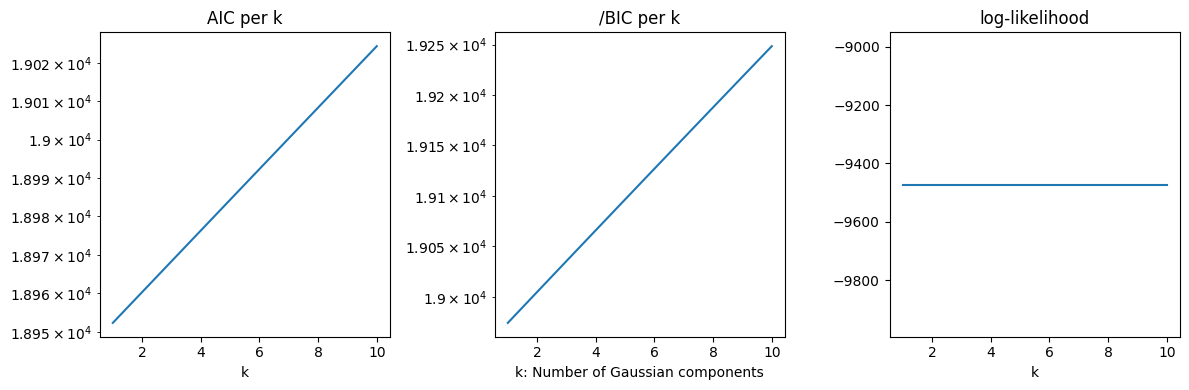

In [70]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].plot(kk, aic)
axs[0].set_yscale('log')
axs[0].set_xlabel('k')
axs[0].set_title('AIC per k')

axs[1].plot(kk, bic)
axs[1].set_yscale('log')
axs[1].set_xlabel('k: Number of Gaussian components')
axs[1].set_title('/BIC per k')

axs[2].plot(kk, loglik)
axs[2].set_xlabel('k')
axs[2].set_title('log-likelihood')

plt.tight_layout()
plt.show()